<table>
    <tr>
        <td><img src="https://s3.amazonaws.com/media-p.slid.es/uploads/1485763/images/9060062/Header.png" width="300"/></td>
        <td>&nbsp;</td>
        <td>
            <h1 style="font-size:200%;color:#6A0DAD;text-align:center"> <FONT COLOR="#6A0DAD"> Regresión Logística</FONT> </h1></td>         
        <td>
            <tp><p style="font-size:99%;text-align:center">Sesión 3</p></tp>
            <tp><p style="font-size:115%;text-align:center">15 de Marzo 2026</p></
            <tp><p style="font-size:115%;text-align:center">Prof. Daniel Rambaut </p></tp>
        </td>
    </tr>
</table>


### <FONT SIZE=4 COLOR="blue">Objetivos de la sesión: </FONT>
✔   **Comprender la clasificación probabilística:** Introducir la Regresión Logística para predecir la probabilidad de ocurrencia de un evento, avanzando más allá de las decisiones basadas puramente en distancias.
<br>
✔   **Controlar el Umbral de Decisión:** Aprender a ajustar el límite matemático (*threshold*) del modelo para minimizar los errores críticos (Falsos Positivos o Falsos Negativos) según las necesidades del problema real.
<br>
✔   **Evaluar modelos dinámicamente:** Implementar la Curva ROC y la métrica AUC (Área Bajo la Curva) para medir y comparar la robustez de los algoritmos frente a múltiples escenarios de decisión simultáneamente.

# <FONT SIZE=5 COLOR="green"> 0. Repaso de la sesión anterior </FONT>

En la sesión pasada profundizamos en la evaluación y mejora de modelos de clasificación, hablando acerca de:

<FONT SIZE=3 COLOR="green"> 1. Matriz de Confusión: </FONT>
<br>
Una herramienta que nos permite tabular el desempeño de un algoritmo, desglosando las predicciones en Verdaderos Positivos (VP), Verdaderos Negativos (VN), Falsos Positivos (FP) y Falsos Negativos (FN), para entender exactamente dónde se equivoca el modelo.
<br><br>
<FONT SIZE=3 COLOR="green"> 2. Métricas de Evaluación Avanzadas: </FONT>
<br>
Comprendimos que la exactitud (*Accuracy*) no siempre es suficiente, especialmente en datos desbalanceados. Exploramos métricas más robustas como la **Precisión** (*Precision*), la **Sensibilidad** (*Recall*) y el **F1-Score**.
<br><br>
<FONT SIZE=3 COLOR="green"> 3. Hiperparámetros vs. Parámetros: </FONT>
<br>
Diferenciamos lo que el modelo aprende por sí solo con los datos (parámetros) de las configuraciones externas que nosotros como analistas debemos definir antes de entrenar (hiperparámetros, como el valor de $k$ o la medida de distancia en KNN).
<br><br>
<FONT SIZE=3 COLOR="green"> 4. Búsqueda en Grilla (Grid Search): </FONT>
<br>
Un método sistemático y automatizado que nos permite probar múltiples combinaciones de hiperparámetros simultáneamente para encontrar el modelo con el mejor rendimiento posible.
<br><br>
<FONT SIZE=3 COLOR="green"> 5. Validación Cruzada (Cross-Validation): </FONT>
<br>
Una técnica robusta para evaluar la capacidad de generalización del modelo. Consiste en dividir el conjunto de entrenamiento en $K$ pliegues (*Folds*), entrenando y probando el algoritmo iterativamente para asegurar que los resultados no sean producto de la casualidad y evitar el sobreajuste (*Overfitting*).
<br><br>
<FONT SIZE=3 COLOR="green"> 6. Preparación y Escalamiento Riguroso: </FONT>
<br>
Consolidamos la importancia de escalar siempre los datos (`StandardScaler`) antes de pasarlos al modelo y asegurarnos de usar exactamente los mismos parámetros de escalamiento aprendidos en el entrenamiento para predecir sobre datos nuevos.

---

# <FONT COLOR="purple">Introducción: </FONT>
En la sesión pasada aprendimos a evaluar rigurosamente nuestro modelo usando la Matriz de Confusión y a optimizarlo para asegurar su estabilidad. Sin embargo, hasta ahora nuestras predicciones han sido absolutas: el modelo (KNN) simplemente decide si una observación pertenece a una categoría o a otra.

Pero en el mundo real, las decisiones requieren matices. **¿Qué pasaría si en lugar de una respuesta rígida, el algoritmo nos dijera la *probabilidad* exacta de que un evento ocurra?** En esta sesión daremos el salto hacia la **Regresión Logística**, un modelo estadístico fundamental que nos permite clasificar basándonos en probabilidades. Además, entenderemos cómo establecer reglas de decisión personalizadas y aprenderemos a evaluar visual y matemáticamente el rendimiento global de nuestro modelo utilizando la **Curva ROC** y la métrica **AUC** (Área Bajo la Curva).

# <FONT SIZE=6 COLOR="purple"> 1. Regresión Logística



## <FONT SIZE=5 COLOR="green">  1.1. Motivación al modelo </FONT>

- Usamos regresión logística para estudiar la probabilidad de una variable categórica cualitativa (por ejemplo, dicotómica)  en función de una o más variables cuantitativas.

- En otras palabras, la regresión logística no permite clasificar directamente, pero si permite determinar una probabilidad de pertenecer a un grupo determinado de la variable categórica. Y luego, de acuerdo con esa probabilidad, tomar una decisión de asignación.



Supongamos que tenemos una variable categórica con dos clase, que las llamaremos $\{0, 1\}$. Entonces, si tratamos de buscar un modelo lineal de la forma

$$y = \beta_0 +\beta_1 x_1 +\epsilon$$

donde $y$ es una variable binaria, no sería un bueno modelo ya que la izquierda de la expresión es continua. Luego, podríamos pensar en no tener una relación directa, sino vía la probabilidad, así:

$$P(y_i=1 \mid X = x_i)= \beta_0+\beta_1x_i$$

Cuando intentamos usar mínimos cuadrados, es fácil ver que el modelo no funciona ya que predecimos valores mayores que 1 y menores que 0.

<center><img src="https://github.com/Fabian830348/cursos/blob/0da91b828112d77dbddb387cbb7043ab8a78f252/Imagen/log1.png?raw=true" alt="centered image" width="500" height="400"></center>

podemos observar que este modelo no se ajusta a los datos. Más aun, si tratamos de predecir un valor, como $x=1.1$, al tratarse de una probabilidad, este valor no tiene sentido, pues es negativo.

Entonces, buscaremos una función cumpla lo siguiente

- $P(y_i=1 \mid X = x_i) = f(\beta_0 + \beta_1 x_i)$

- $P(y_i=1 \mid  x_i)$ sea creciente en $x$ para $\beta_1>0$.

- $P(y_i=1 \mid  x_i)$ sea decreciente en $x$ para $\beta_1<0$.

- $0 \leq P(y_i=1 \mid  x_i) \leq 1$ para todo valor de $x_i$.

Se puede ver rápidamente que la función debería tener una forma de S. A esta función se le denomina función sigmoide y es la base del modelo logístico

$$f(x)= \dfrac{e^x}{1+e^x}$$

La gráfica de esta función es:

<center><img src="https://github.com/Fabian830348/cursos/blob/0da91b828112d77dbddb387cbb7043ab8a78f252/Imagen/log2.png?raw=true" alt="centered image" width="500" height="400"></center>

Así pues, tenemos una expresión de la forma

$$P(y_i=1 \mid  X = x_i)= \dfrac{e^{\beta_0+\beta_1x_i}}{1+e^{\beta_0+\beta_1x_i}}$$


## <FONT SIZE=5 COLOR="purple"> 1.2. Implementacion del modelo </FONT>


### <FONT SIZE=5 COLOR = "green"> 1.2.1. Introducción al Problema: Predicción de Riesgo Cardiovascular </FONT>

En este ejercicio, trabajaremos con un conjunto de datos clínicos. El objetivo es determinar la probabilidad de que un paciente presente niveles de **Colesterol Alto (1)** o **Normal (0)**.

Este es un problema clásico de clasificación binaria donde la Regresión Logística destaca, ya que no solo nos indicará qué pacientes tienen riesgo, sino qué tan seguros estamos de esa predicción mediante el cálculo de una probabilidad matemática.

A continuación, se describen las variables clínicas recolectadas para cada paciente en nuestro conjunto de datos:

- ***Edad***: Edad del paciente expresada en años.
- ***Sexo***: Género biológico del paciente.
- ***PS***: Nivel de presión sanguínea.
- ***Na***: Concentración de Sodio en la sangre.
- ***K***: Concentración de Potasio en la sangre.
- ***Droga***: Tipo de medicamento administrado al paciente, hay 4 clases.
- ***Colesterol***: Variable objetivo que queremos predecir:
   - $1$ : El paciente presenta niveles de colesterol alto.
   - $0$ : El paciente presenta niveles de colesterol normales.


### <FONT SIZE=5 COLOR="green"> 1.2.2. Exploración y Preparación de Datos </FONT>

Antes de modelar, es fundamental entender con qué información contamos. Por lo tanto, realizamos un análisis descriptivo básico para conocer las dimensiones del dataset y evaluar el balance de la variable objetivo.

In [33]:
# carga de librerias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm
import statsmodels.formula.api as smf

from statsmodels.stats.weightstats import ttest_ind
from pylab import rcParams
from collections import Counter

# Ignorar warnings
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')

In [34]:
# Carga del dataset (Ajusta la ruta según tu entorno)
url = "https://github.com/drambaut/APRENDIZAJE-AUTOMATICO-DE-MAQUINA-I-/raw/refs/heads/main/datasets/Colesterol.xlsx"
df=pd.read_excel(url)
df.head(n=5)

,Edad,Sexo,PS,Na,K,Droga,Colesterol
0,23,F,ALTO,0.792535,0.031258,drogaY,ALTO
1,47,M,BAJO,0.739309,0.056468,drogaC,ALTO
2,47,M,BAJO,0.697269,0.068944,drogaC,ALTO
3,28,F,NORMAL,0.563682,0.072289,drogaX,ALTO
4,61,F,BAJO,0.559294,0.030998,drogaY,ALTO


### <FONT SIZE=5 COLOR="green"> 1.2.3. Dummificacion </FONT>
La **dummificación** (o creación de variables dummy) es un proceso de preprocesamiento de datos que convierte variables categóricas (texto o etiquetas) en **variables numéricas binarias**.
<br>
Dado que la mayoría de los algoritmos de aprendizaje automático solo procesan números, se crea una nueva columna para cada categoría posible. Si un registro pertenece a esa categoría, se le asigna un 1; de lo contrario, se le asigna un 0. Por ejemplo, una columna "Color" con "Rojo" y "Azul" se transforma en dos columnas distintas donde solo una puede estar activa a la vez.

En nuestro caso, por ejemplo, tenemos variables como **sexo**, **PS**, **Droga**, **Colesterol** que son variables strings y necesitamos de ellas para entrenar nuestro modelo, así que las transformamos en vairbales **Dummies**.

In [35]:
# Preparación del dataset: variables dummies
df = pd.get_dummies(df, columns=['Sexo'],prefix='Sexo')
df = pd.get_dummies(df, columns=['PS'], prefix='PS')
df = pd.get_dummies(df, columns=['Droga'], prefix='Droga')


In [36]:
# Eliminar una de las dummies para evitar colinealidad
df.drop('Sexo_M', axis=1, inplace=True)
df.drop('PS_ALTO', axis=1, inplace=True)
df.drop('Droga_drogaA', axis=1, inplace=True)

In [37]:
# Creamos dummies
df['Sexo_F'] = df['Sexo_F'].replace({True: 1, False: 0}).astype(int)
df['PS_BAJO'] = df['PS_BAJO'].replace({True: 1, False: 0}).astype(int)
df['PS_NORMAL'] = df['PS_NORMAL'].replace({True: 1, False: 0}).astype(int)
df['Droga_drogaB'] = df['Droga_drogaB'].replace({True: 1, False: 0}).astype(int)
df['Droga_drogaC'] = df['Droga_drogaC'].replace({True: 1, False: 0}).astype(int)
df['Droga_drogaX'] = df['Droga_drogaX'].replace({True: 1, False: 0}).astype(int)
df['Droga_drogaY'] = df['Droga_drogaY'].replace({True: 1, False: 0}).astype(int)
df['Colesterol'] = df['Colesterol'].replace({'ALTO': 1, 'NORMAL': 0}).astype(int)

In [38]:
# vemos cómo quedó el dataset:
df.head(n=5)

,Edad,Na,K,Colesterol,Sexo_F,PS_BAJO,PS_NORMAL,Droga_drogaB,Droga_drogaC,Droga_drogaX,Droga_drogaY
0,23,0.792535,0.031258,1,1,0,0,0,0,0,1
1,47,0.739309,0.056468,1,0,1,0,0,1,0,0
2,47,0.697269,0.068944,1,0,1,0,0,1,0,0
3,28,0.563682,0.072289,1,1,0,1,0,0,1,0
4,61,0.559294,0.030998,1,1,1,0,0,0,0,1


In [39]:
# revisamos cómo es la estructura del dataset, la informacion
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Edad          200 non-null    int64  
 1   Na            200 non-null    float64
 2   K             200 non-null    float64
 3   Colesterol    200 non-null    int64  
 4   Sexo_F        200 non-null    int64  
 5   PS_BAJO       200 non-null    int64  
 6   PS_NORMAL     200 non-null    int64  
 7   Droga_drogaB  200 non-null    int64  
 8   Droga_drogaC  200 non-null    int64  
 9   Droga_drogaX  200 non-null    int64  
 10  Droga_drogaY  200 non-null    int64  
dtypes: float64(2), int64(9)
memory usage: 17.3 KB


### <FONT SIZE=5 COLOR="green"> 1.2.4. Implementación de la Regresión Logística </FONT>

A diferencia de algoritmos como KNN, la Regresión Logística asume una relación lineal entre las variables de entrada y el logaritmo de las probabilidades de pertenecer a una clase específica.

### <FONT SIZE=4 COLOR="green"> División y Escalamiento </FONT>
Como aprendimos en la sesión pasada, los algoritmos basados en optimización matemática (como el descenso de gradiente utilizado internamente en este modelo) requieren estrictamente que los datos estén en la misma escala para converger de manera adecuada.

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# División de df
X = df.drop(columns = 'Colesterol')
y = df['Colesterol']
X_train, X_test, y_train, y_test = train_test_split(
                                        X,
                                        y.values.reshape(-1,1),
                                        train_size   = 0.7,
                                        random_state = 1234, # semilla
                                        shuffle      = True
                                    )


In [41]:
# Verificamos particion de df
print(np.shape(df))
print(np.shape(X_train))
print(np.shape(y_train))
print(np.shape(X_test))
print(np.shape(y_test))


(200, 11)
(140, 10)
(140, 1)
(60, 10)
(60, 1)


In [42]:
# Crear modelo
log_reg = LogisticRegression()

# Entrenar con TRAIN
log_reg.fit(X_train, y_train)

# Predicciones
y_train_pred = log_reg.predict(X_train)
y_test_pred = log_reg.predict(X_test)

print("Modelo entrenado ✔")


Modelo entrenado ✔


### <FONT SIZE=5 COLOR="green"> 1.2.5. Interpretación de Parámetros </FONT>

Una de las mayores ventajas de la Regresión Logística frente a algoritmos de "caja negra" o basados en distancias es su alta **interpretabilidad**. Podemos cuantificar exactamente cuánto influye cada variable predictora en la probabilidad final.

<FONT SIZE=3 COLOR="purple"> ¿Qué nos indican los coeficientes? </FONT>
* **Coeficientes Positivos:** A medida que el valor de la variable aumenta, la probabilidad de pertenecer a la clase 1 (Colesterol Alto) aumenta.
* **Coeficientes Negativos:** A medida que el valor de la variable aumenta, la probabilidad de pertenecer a la clase 1 disminuye.
<br>

Por ejemplo, si observamos la tabla de coeficientes:
<br>

* Variables con coeficientes **positivos grandes** tienen mayor influencia en aumentar la probabilidad estimada de colesterol alto.
* Variables con coeficientes **negativos** indican una relación inversa con dicha probabilidad dentro de este conjunto de datos.
<br><br>
Es importante recordar que estos coeficientes describen **relaciones estadísticas encontradas en los datos**, y no necesariamente implican una relación causal en el mundo real.

,Variable,Coeficiente
7,Droga_drogaC,1.836540
5,PS_NORMAL,1.224689
3,Sexo_F,0.200513
9,Droga_drogaY,0.026974
0,Edad,0.019514
4,PS_BAJO,-0.030110
1,Na,-0.047704
2,K,-0.065016
6,Droga_drogaB,-0.225669
8,Droga_drogaX,-1.393864


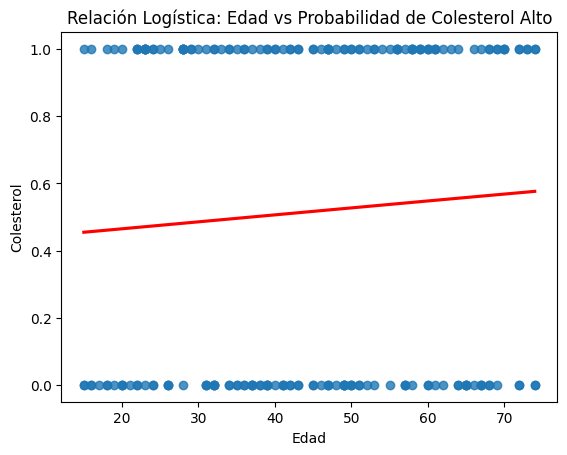

In [43]:
# Extracción de coeficientes
importancia = pd.DataFrame({
    'Variable': X_train.columns,
    'Coeficiente': log_reg.coef_[0]
})

display(importancia.sort_values(by='Coeficiente', ascending=False))

# Visualización logística
sns.regplot(
    x='Edad',
    y='Colesterol',
    data=df,
    logistic=True,
    ci=None,
    line_kws={'color': 'red'}
)

plt.title("Relación Logística: Edad vs Probabilidad de Colesterol Alto")
plt.show()

<FONT SIZE=5 COLOR="green">Interpretación </FONT>

Una vez entrenado el modelo de regresión logística, podemos analizar los **coeficientes estimados** para entender cómo cada variable influye en la predicción.

<FONT SIZE=4 COLOR=pruple>Interpretación de las probabilidades</FONT>

Además de generar una predicción final (`0` o `1`), el modelo calcula una **probabilidad estimada** para cada observación.

Por ejemplo, si el modelo asigna una probabilidad de `0.85` a un paciente, significa que el modelo estima un **85 % de probabilidad** de que ese paciente pertenezca a la clase de colesterol alto.

Para convertir estas probabilidades en una clasificación final, se utiliza un **umbral de decisión**. Generalmente se usa el valor por defecto:

$\text{umbral} = 0.5$

Esto significa que:

* Probabilidad ≥ 0.5 → se clasifica como `1`
* Probabilidad < 0.5 → se clasifica como `0`



 <FONT SIZE=4 COLOR="green"> Ejercicios de entendimiento </FONT>
 <br><br>
**Ejercicio 1.**
<br>Por favor escribe a continuación qué sigifican estos coeficientes en el modelo de regresión logistica, qué variable es la más importante? por qué?

*Escriba su respuesta aquí*

### <FONT SIZE=5 COLOR="green">1.2.6. Probabilidades de Clasificación </FONT>

En este punto es donde conectamos el modelo probabilístico con el concepto de **Umbral de Decisión**. El modelo logístico genera una probabilidad continua entre 0 y 1, y somos nosotros, como analistas, quienes debemos establecer el punto de corte exacto a partir del cual consideramos que un paciente debe ser clasificado con colesterol alto.

In [51]:
# Obtener probabilidades para el conjunto de prueba
probs = log_reg.predict_proba(X_test)[:, 1]

# Crear DataFrame de comparación
comparativa = pd.DataFrame({
    'Probabilidad_Clase1': probs,
    'Clase_Predicha_umbral_0.5': (probs >= 0.5).astype(int),
    'Clase_Real': y_test.ravel()
})

display(comparativa.head(10))

,Probabilidad_Clase1,Clase_Predicha_umbral_0.5,Clase_Real
0,0.474694,0,1
1,0.520696,1,1
2,0.565220,1,1
3,0.676831,1,1
4,0.183561,0,0
5,0.432410,0,1
6,0.379003,0,1
7,0.838675,1,1
8,0.466832,0,1
9,0.555537,1,0


En la sección 3. profundizaremos acerca de este umbral de decisión, ya que es uno de esos hiperparametros que podemos ajsutar para que el modelo tome mejores decisiones.


### <FONT SIZE=5 COLOR="green">Metricas del modelo</FONT>

En este punto es donde conectamos el modelo probabilístico con el concepto de **Umbral de Decisión**. El modelo logístico genera una probabilidad continua entre 0 y 1, y somos nosotros, como analistas, quienes debemos establecer el punto de corte exacto a partir del cual consideramos que un paciente debe ser clasificado con colesterol alto.

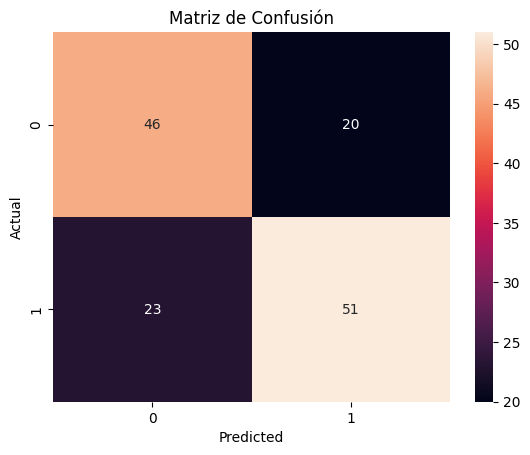

In [45]:
# Matriz de confusión  (Heatmap)
conf_matrix = confusion_matrix(y_train, y_train_pred)
sns.heatmap(conf_matrix, annot=True, fmt="d")
plt.title('Matriz de Confusión')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

 <FONT SIZE=4 COLOR="green"> Ejercicio de refuerzo </FONT>
 <br><br>
**Ejercicio 2.**
<br>
* Interpretar la matriz de confusión y concluir la performance del modelo.
* Adicionalmente obtener las métricas de accuracy, recall y F1, interpretar.
* ¿Por qué cree que el modelo no es mejor? ¿cómo lo mejoraría?

*Escriba aquí su respuesta*

# <FONT SIZE=5 COLOR="purple"> 2. Curva ROC (Receiver operating characteristic) </FONT>

- Formalmente, la ***curva ROC*** es la representación gráfica de la razón o proporción de verdaderos positivos (TPR = True positive rate) frente a la razón o proporción de falsos positivos (FPR = False positive rate) según se varía el umbral de discriminación (valor a partir del cual decidimos que un caso es un positivo).

- Ahora, la curva ROC se aplica para evaluar algoritmos de *machine learning* y hacer comparación del rendimiento de estos.


## <FONT SIZE=4 COLOR="Green"> 2.2. AUC : Área bajo la curva ROC </FONT>

- En el campo de machine learning el **área bajo la curva ROC** (***AUC***) es un instrumento para evaluar modelos de clasificación.

- El AUC esta relacionado con el índice de Gini:

$$Gini = 2 \times AUC -1$$

- Este puntaje nos da una buena idea de qué tan bien funciona el modelo.

- Un modelo será mejor en cuanto su *AUC* este más cercano a $1$. Es decir, que la curva ROC sea más parecida a $y=1$. Sin embargo, hay que tener cuidado con un modelo con $AUC=1$, pues puede significar *overfitting* en el modelo.

<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/master/ROC/roc8.png?raw=true" alt="centered image" width="450" height="450"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia   </FONT> <figcaption></center>

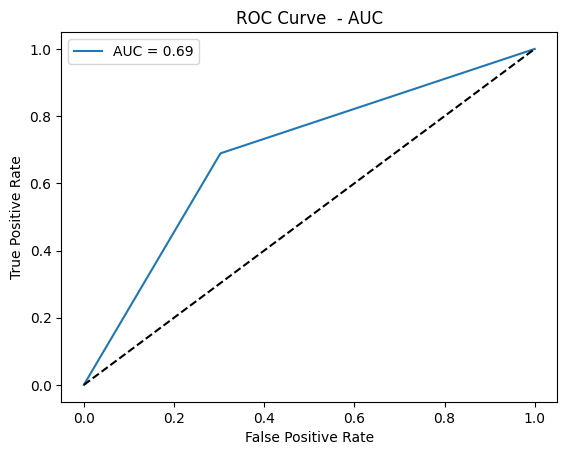

In [53]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_train, y_train_pred)
roc_auc = roc_auc_score(y_train, y_train_pred)

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve  - AUC')
plt.legend(loc='best')
plt.show()

En este caso, con $AUC = 0.69$, el modelo tendría aproximadamente un $69\%$ de probabilidad de ordenar correctamente esos dos casos.

<FONT SIZE=5 COLOR=green> Reflexión sobre la evaluación del modelo</FONT>

Sin embargo, evaluar el modelo utilizando **un único umbral** puede ser limitante. Dependiendo del problema, podría ser más importante detectar la mayor cantidad posible de casos positivos, o bien minimizar los falsos positivos.

Por esta razón, en Machine Learning es común analizar el desempeño del modelo utilizando **diferentes umbrales de decisión**, lo que permite comprender mejor su comportamiento y robustez en distintos escenarios.

# <FONT SIZE=5 COLOR="green"> 3. El Umbral de Decisión (Threshold) </FONT>



## <FONT SIZE=4 COLOR="green">3.1. ¿Qué es el Umbral de Decisión? </FONT>

En los modelos probabilísticos como la Regresión Logística, el algoritmo no predice directamente a qué clase discreta pertenece una observación (por ejemplo, 0 o 1). En su lugar, calcula una **probabilidad continua entre 0 y 1**. Para convertir este resultado numérico en una categoría definitiva, se debe establecer un punto de corte. A este límite matemático se le conoce como **umbral de clasificación** o *threshold*.

Los ejemplos con una probabilidad predicha superior o igual al valor del umbral se asignan a la clase positiva (la que estamos buscando), y aquellos con una probabilidad inferior se asignan a la clase negativa.

<p align="center">
  <img src="https://miro.medium.com/v2/resize:fit:640/format:webp/0*KZu2_AY6Oxr86dWd.png" width="600"/>
  <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: https://morihosseini.medium.com/mastering-logistic-regression-thresholds-b34fe07f09f5   </FONT> <figcaption></center>
</p>


## <FONT SIZE=4 COLOR="green">3.2. ¿Para qué se utiliza en Machine Learning? </FONT>

El umbral se utiliza para controlar la rigurosidad del modelo y gestionar el equilibrio (**trade-off**) entre los distintos tipos de errores (Falsos Positivos y Falsos Negativos). Por defecto, la mayoría de las librerías (como Scikit-Learn) establecen este umbral en **0.5** (50%). Sin embargo, utilizar este valor por defecto no es recomendable si el costo operativo de un tipo de clasificación incorrecta es mayor que el otro, o si las clases dentro de la base de datos están fuertemente desbalanceadas.



## <FONT SIZE=4 COLOR="green"> 3.2.1. Ejemplo de uso: Caso hipotetico - Filtro de Correos Spam </FONT>

Supongamos que implementamos un modelo de regresión logística en una aplicación de correo para filtrar mensajes no deseados (*spam*). El modelo evalúa dos correos entrantes:
* **Correo A:** Obtiene una predicción de **0.99** (99% de probabilidad de ser *spam*).
* **Correo B:** Obtiene una predicción de **0.51** (51% de probabilidad de ser *spam*).

Si mantenemos el umbral predeterminado de **0.5**, el modelo clasificará **ambos** correos como *spam* y los enviará a la bandeja de correo no deseado. Si, por el contrario, elevamos el umbral a **0.95**, solo el Correo A será clasificado como *spam*.

**La decisión de negocio:** En este escenario, clasificar un correo legítimo de trabajo como *spam* (Falso Positivo) es un error mucho más crítico que permitir que un correo publicitario llegue a la bandeja principal (Falso Negativo). Por lo tanto, dejar el umbral en 0.5 produciría resultados no deseados, filtrando correos de los cuales el modelo no está muy seguro (como el Correo B). El analista debe ajustar manualmente el umbral hacia arriba (por ejemplo, a 0.85) para exigirle al modelo mayor "certeza" antes de ocultar un mensaje al usuario.

### <FONT SIZE=4 COLOR="green"> 3.2.2. Ejercicio: Ajustando el Umbral </FONT>
Imagina que este modelo será usado en una zona rural con pocos médicos. El hospital decide que **no puede permitirse dejar ir a nadie que realmente tenga colesterol alto** (quieren minimizar los Falsos Negativos), aunque eso signifique hacerle pruebas extra a gente sana (aumentar Falsos Positivos).

**Tu tarea:**
1. ¿Hacia dónde moverías el umbral de decisión? ¿lo aumentarías o lo bajarías?
2. Explica qué sucedería con la **Sensibilidad (Recall)** del modelo al realizar este cambio.

*Escriba su respuesta aquí*


## <FONT SIZE=4 COLOR="green"> 3.3. Umbrales del modelo de regresión Logística </FONT>

Por último, exploraremos cómo **cambia la clasificación de nuestro modelo de regresión logística** al variar el **umbral de decisión**.  
Recordemos que el modelo calcula probabilidades de pertenecer a la clase positiva (colesterol alto), pero la **decisión final de 0 o 1 depende del umbral que elijamos**.  

- Para **umbral bajo (0.3)**, se clasifican más observaciones como positivas, lo que aumenta la **sensibilidad** pero también los **falsos positivos**.  
- Para **umbral medio (0.5)**, usamos el umbral por defecto.  
- Para **umbral alto (0.7)**, se requiere mayor probabilidad para clasificar como positiva, lo que reduce falsos positivos pero puede aumentar falsos negativos.  

**Nota importante:** La curva ROC y el AUC no cambian con el umbral porque dependen solo de las probabilidades que calcula el modelo. Lo que cambia es **cómo convertimos esas probabilidades en clases** para evaluar métricas como matriz de confusión, precisión y recall.

In [56]:
umbral_1 = 0.3
umbral_2 = 0.5
umbral_3 = 0.7

comparativa = pd.DataFrame({
    'Probabilidad_Clase1': probs,
    f'Prediccion_umbral_{umbral_1}': (probs >= umbral_1).astype(int),
    f'Prediccion_umbral_{umbral_2}': (probs >= umbral_2).astype(int),
    f'Prediccion_umbral_{umbral_3}': (probs >= umbral_3).astype(int),
    'Clase_Real': y_test.ravel()
})

display(comparativa.head(10))

,Probabilidad_Clase1,Prediccion_umbral_0.3,Prediccion_umbral_0.5,Prediccion_umbral_0.7,Clase_Real
0,0.474694,1,0,0,1
1,0.520696,1,1,0,1
2,0.565220,1,1,0,1
3,0.676831,1,1,0,1
4,0.183561,0,0,0,0
5,0.432410,1,0,0,1
6,0.379003,1,0,0,1
7,0.838675,1,1,1,1
8,0.466832,1,0,0,1
9,0.555537,1,1,0,0


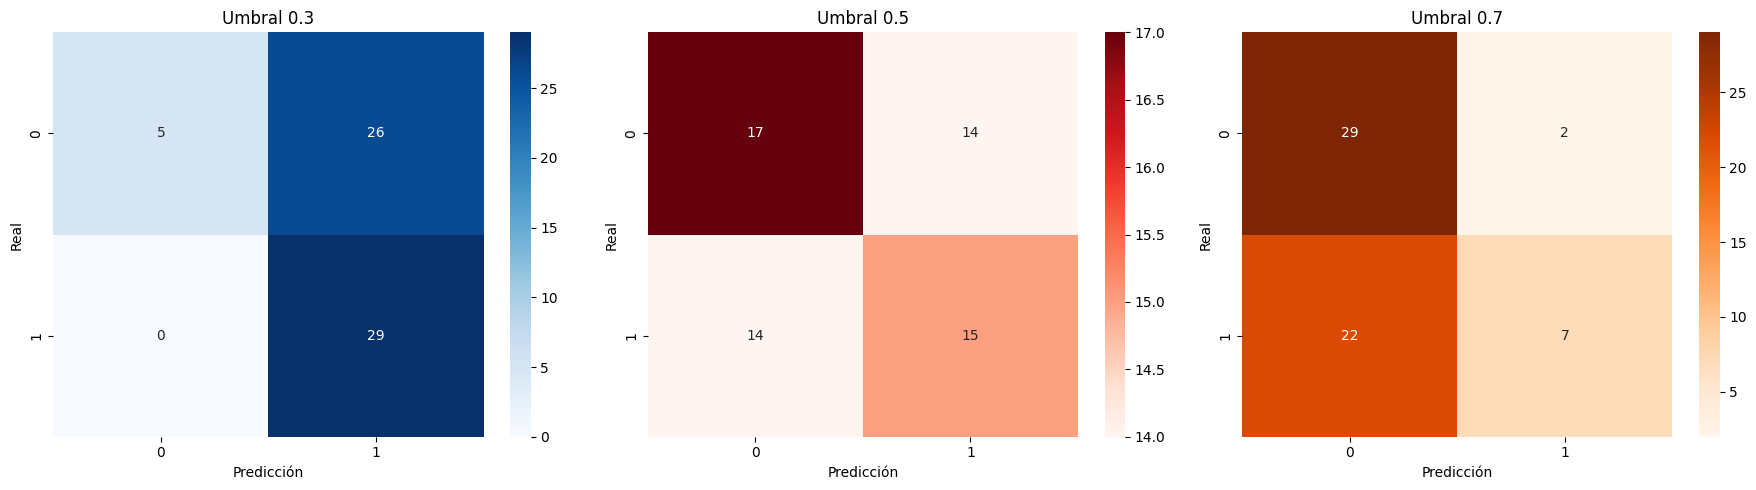

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Probabilidades clase positiva en test
probs_test = log_reg.predict_proba(X_test)[:, 1]

# Lista de umbrales y colores
umbrales = [0.3, 0.5, 0.7]
colores = ["Blues", "Reds", "Oranges"]

# Crear figura con 1 fila y 3 columnas
fig, axes = plt.subplots(1, 3, figsize=(18,5))

for i, umbral in enumerate(umbrales):
    # Clasificación con el umbral
    y_test_pred_umbral = (probs_test >= umbral).astype(int)

    # Matriz de confusión
    conf_matrix = confusion_matrix(y_test, y_test_pred_umbral)

    # Dibujar heatmap
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap=colores[i], ax=axes[i])
    axes[i].set_title(f'Umbral {umbral}')
    axes[i].set_xlabel('Predicción')
    axes[i].set_ylabel('Real')

plt.tight_layout()
plt.show()